# Training logs: TFBind and Hypergrid

Set `LOG_PATH` below to a run directory, its `logs.jsonl` file, or a parent directory containing runs. A parent directory selects the most recently updated run. Run all cells to plot every scalar metric and the saved evaluation data. Set `EVAL_STEP` to inspect an earlier evaluation; `None` selects the latest.

Logging defaults to JSON, without Comet credentials or a network connection:

```bash
python run.py algorithm=prefix_tb_tfbind
python run.py algorithm=prefix_tb_hypergrid log_dir=/path/to/logs
python run.py algorithm=prefix_tb_tfbind logger=comet
```

Each run contains:
- `run.json`: configuration, run name, status, and any error.
- `logs.jsonl`: append-only JSON records for metrics and artifact paths, flushed after each event.
- `data/*.npz`: target and empirical distributions, terminal samples, trajectory lengths, and replay histograms.
- `figures/*.png`: evaluation figures.
- `checkpoint.msgpack`: the latest model parameters, optimizer state, and training step. Every evaluation replaces this same file.

The plots need NumPy, Matplotlib, and IPython; they do not require JAX or Comet. TV uses the rolling sample buffer. Length statistics and terminal samples describe the fresh evaluation batch. `target/tv` compares two independent target subsets, each of size `eval_buffer_size`.

Every run creates a unique `run_<timestamp>_<id>/` subdirectory beneath `log_dir` (or beneath Hydra's run directory by default). You can reuse the same `log_dir` across runs. Each run has separate JSON logs, artifacts, and one checkpoint that is overwritten during that run. Set `LOG_PATH` to the parent to open the latest run, or to a specific run directory.


In [1]:
import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, JSON, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
LOG_PATH = PROJECT_ROOT / "outputs"  # Change to your run directory or logs.jsonl.
EVAL_STEP = None                     # None = latest; otherwise a training step.
LOG_Y_METRICS = {"loss"}              # Use set() for entirely linear axes.
SHOW_SAVED_FIGURES = True


In [2]:
log_path = Path(LOG_PATH).expanduser()
if log_path.is_dir():
    candidates = list(log_path.rglob("logs.jsonl"))
    if not candidates:
        raise FileNotFoundError(f"No logs.jsonl found under {log_path}; set LOG_PATH to a run.")
    log_path = max(candidates, key=lambda path: path.stat().st_mtime)

run_dir = log_path.parent
text = log_path.read_text()
lines = text.splitlines()
events = []
for index, line in enumerate(lines):
    if not line.strip():
        continue
    try:
        events.append(json.loads(line))
    except json.JSONDecodeError:
        # A running or interrupted job may have one unfinished trailing record.
        if index == len(lines) - 1 and not text.endswith("\n"):
            print("Ignoring an incomplete trailing log record.")
        else:
            raise

metadata_path = run_dir / "run.json"
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}
print(f"Run: {run_dir.resolve()}")
print(f"Status: {metadata.get('status', 'unknown')}; records: {len(events)}")
display(JSON(metadata))


Run: /Users/kkorolev/mml/gfn_ot/outputs/2026-09-18/15-02-56/run_20260918_120256_664966_flk2jllp
Status: running; records: 124


<IPython.core.display.JSON object>

## All scalar metrics

The horizontal axis is the number of completed training updates. Evaluation metrics and training losses can be recorded at different frequencies. Missing or non-finite values are omitted.


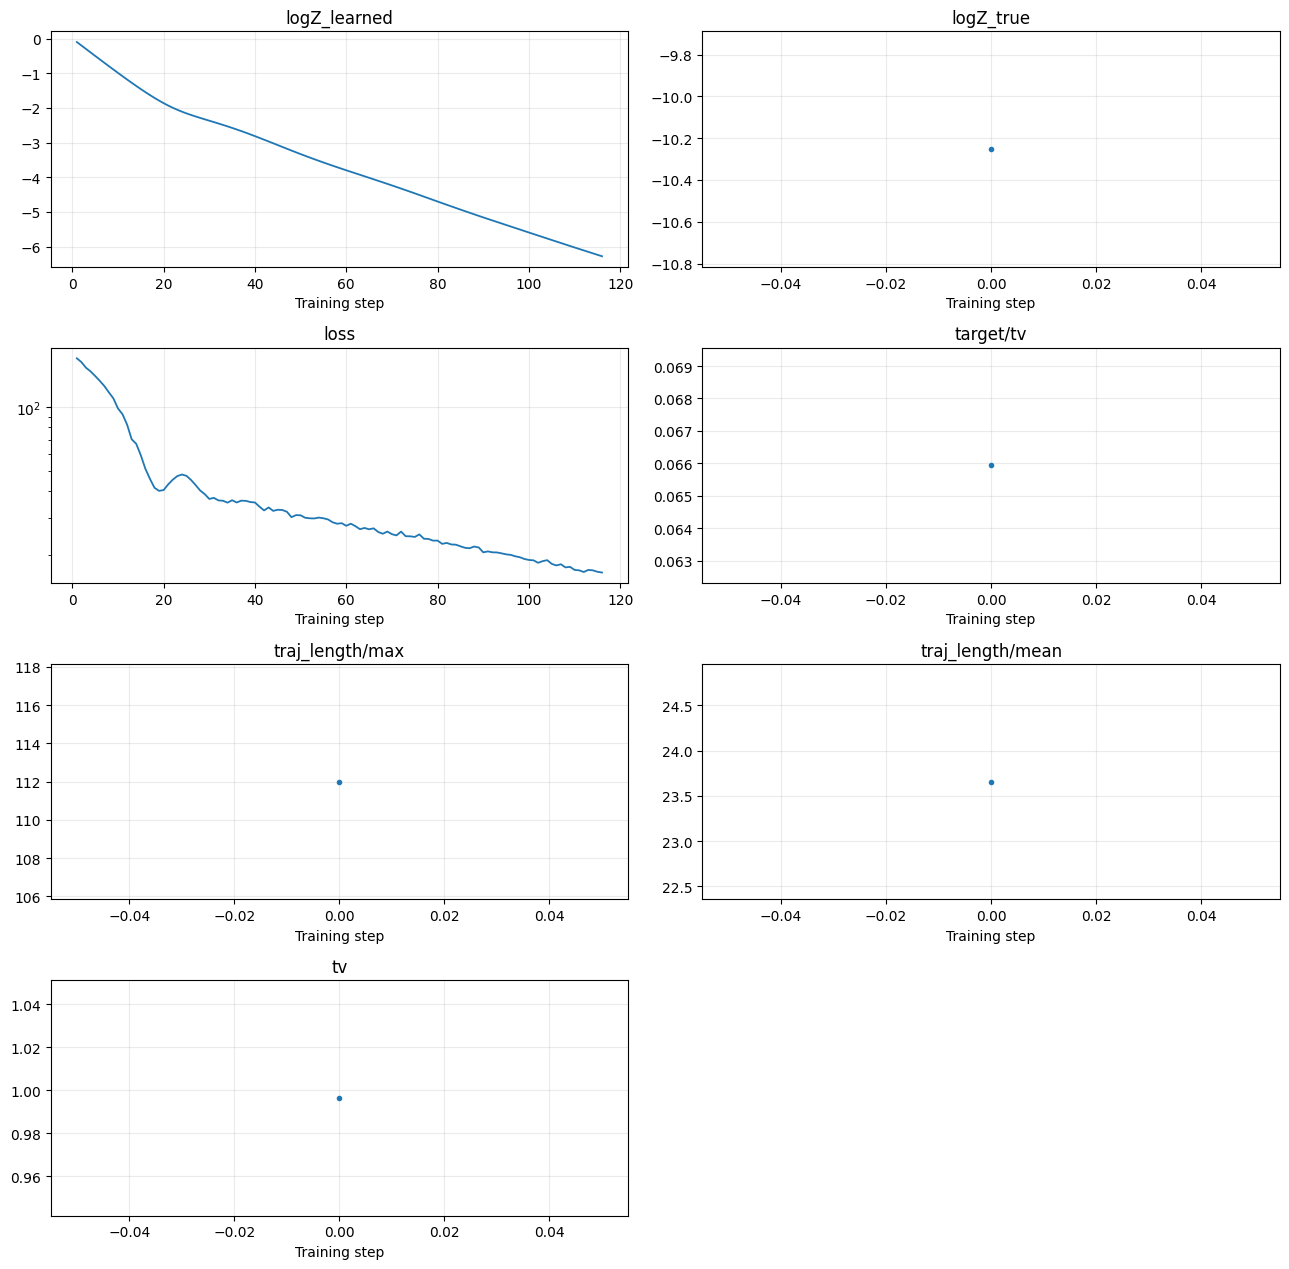

In [3]:
metric_events = [event for event in events if event["type"] == "metrics"]
metric_names = sorted({name for event in metric_events for name in event["metrics"]})
if not metric_names:
    print("No scalar metrics have been logged yet.")
else:
    rows = math.ceil(len(metric_names) / 2)
    fig, axes = plt.subplots(rows, 2, figsize=(13, 3.2 * rows), squeeze=False)
    for ax, name in zip(axes.flat, metric_names):
        points = [(event["step"], event["metrics"][name]) for event in metric_events
                  if name in event["metrics"] and event["metrics"][name] is not None]
        points.sort(key=lambda point: point[0])
        if points:
            steps, values = np.asarray(points).T
            ax.plot(steps, values, linewidth=1.3, marker="." if len(points) < 20 else None)
            if name in LOG_Y_METRICS and np.all(values > 0):
                ax.set_yscale("log")
        ax.set(title=name, xlabel="Training step")
        ax.grid(alpha=0.25)
    for ax in list(axes.flat)[len(metric_names):]:
        ax.set_visible(False)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Saved evaluation data

Every logged array is available below. Distributions on TFBind's eight-dimensional state space are shown as position marginals. Two-dimensional Hypergrid distributions are heatmaps. Terminal samples and trajectory lengths are shown separately. Change `EVAL_STEP` in the settings cell and rerun these cells to inspect another evaluation.


In [ ]:
array_events = [event for event in events if event["type"] == "array"]
figure_events = [event for event in events if event["type"] == "figure"]
available_steps = sorted({event["step"] for event in array_events + figure_events})
selected_step = EVAL_STEP if EVAL_STEP is not None else (available_steps[-1] if available_steps else 0)
print(f"Selected step: {selected_step}")
print(f"Available artifact steps: {available_steps}")

def latest_by_name(records, step):
    selected = {}
    for event in records:
        if event["step"] <= step and (
            event["name"] not in selected or event["step"] >= selected[event["name"]]["step"]
        ):
            selected[event["name"]] = event
    return selected

selected_arrays = latest_by_name(array_events, selected_step)
if selected_arrays:
    table = "| Array | Step | Shape | File |\n|---|---:|---|---|\n"
    table += "\n".join(
        f"| {name} | {record['step']} | {record['shape']} | {record['path']} |"
        for name, record in sorted(selected_arrays.items())
    )
    display(Markdown(table))

def read_array(record):
    with np.load(run_dir / record["path"], allow_pickle=False) as archive:
        return archive["data"].copy()

arrays = {name: read_array(record) for name, record in selected_arrays.items()}


In [ ]:
for name, values in sorted(arrays.items()):
    step = selected_arrays[name]["step"]
    fig, ax = plt.subplots(figsize=(8, 4))
    if name.endswith("_dist") and values.ndim > 2:
        marginals = np.stack([
            values.sum(axis=tuple(axis for axis in range(values.ndim) if axis != position))
            for position in range(values.ndim)
        ], axis=1)
        image = ax.imshow(marginals, origin="lower", aspect="auto")
        if values.shape == (4,) * 8:
            ax.set_yticks(range(4), ["A", "C", "G", "T"])
        ax.set(xlabel="Position", ylabel="Token")
        fig.colorbar(image, ax=ax, label="Marginal probability")
    elif name == "terminal_states" and values.ndim == 2:
        if values.shape[1] == 2:
            states, counts = np.unique(values, axis=0, return_counts=True)
            image = ax.scatter(states[:, 0], states[:, 1], c=counts, s=45, cmap="viridis")
            ax.set(xlabel="Coordinate 0", ylabel="Coordinate 1")
            fig.colorbar(image, ax=ax, label="Sample count")
        else:
            tokens = np.unique(values)
            frequencies = np.stack([(values == token).mean(axis=0) for token in tokens])
            image = ax.imshow(frequencies, origin="lower", aspect="auto", vmin=0, vmax=1)
            ax.set_yticks(range(len(tokens)), tokens)
            ax.set(xlabel="Position", ylabel="Token")
            fig.colorbar(image, ax=ax, label="Sample frequency")
    elif name == "trajectory_lengths":
        ax.hist(values.reshape(-1), bins=min(50, int(np.ptp(values)) + 1))
        ax.set(xlabel="Trajectory length", ylabel="Count")
        print(f"{name}: mean={values.mean():.3f}, max={values.max()}, samples={values.size}")
    elif values.ndim == 2:
        image = ax.imshow(values, origin="lower", aspect="auto")
        fig.colorbar(image, ax=ax)
        ax.set(xlabel="Coordinate 1", ylabel="Coordinate 0")
    else:
        ax.plot(values.reshape(-1))
        ax.set(xlabel="Index", ylabel="Value")
    if name.endswith("_dist"):
        print(f"{name}: total probability={values.sum():.8f}")
    ax.set_title(f"{name} — step {step}")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Original saved figures

These are the exact images produced by the trainers. The latest available image at or before `EVAL_STEP` is shown for each figure name.


In [ ]:
if SHOW_SAVED_FIGURES:
    for name, record in sorted(latest_by_name(figure_events, selected_step).items()):
        display(Markdown(f"**{name} — step {record['step']}**"))
        display(Image(filename=str(run_dir / record["path"])))


## Latest checkpoint

Only one checkpoint file is retained; selecting an earlier evaluation above does not restore older weights. The checkpoint stores the Flax `TrainState` (parameters including `logZ`, optimizer state, and update count). It does not store the training replay buffer, evaluation buffer, or random generator state.

To load it in training code, initialize a matching model with that run's configuration and call:

```python
from utils.experiment_logger import load_checkpoint
model_state = load_checkpoint(checkpoint_path, initialized_model_state)
```


In [ ]:
checkpoint_events = [event for event in events if event["type"] == "checkpoint"]
if checkpoint_events:
    latest = checkpoint_events[-1]
    checkpoint_path = run_dir / latest["path"]
    print(f"Checkpoint: {checkpoint_path.resolve()}")
    print(f"Saved training step: {latest['step']}")
    print(f"Exists: {checkpoint_path.is_file()}")
else:
    print("No evaluation checkpoint has been saved yet.")
